## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
import torch
import pickle

sys.path.insert(0, "../../../Mamoth")
sys.path.insert(0, "../../../Modules")

from utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_EL = 'θεσσαλιας'

In [4]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [5]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [6]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'THESSALY'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [7]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [8]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

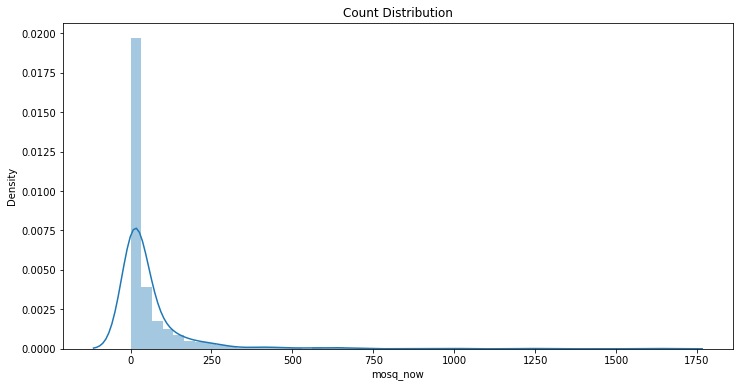

In [9]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [10]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

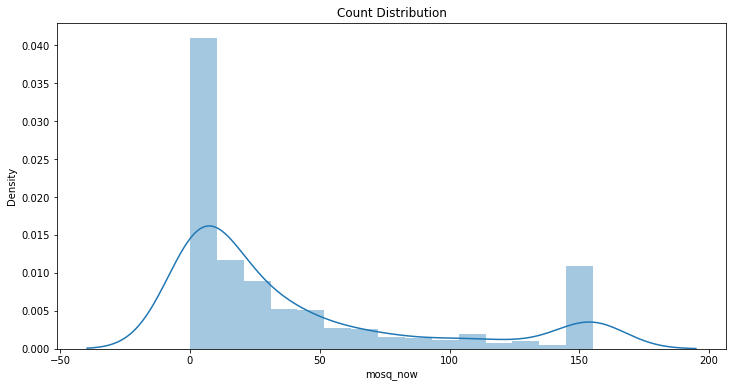

In [11]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

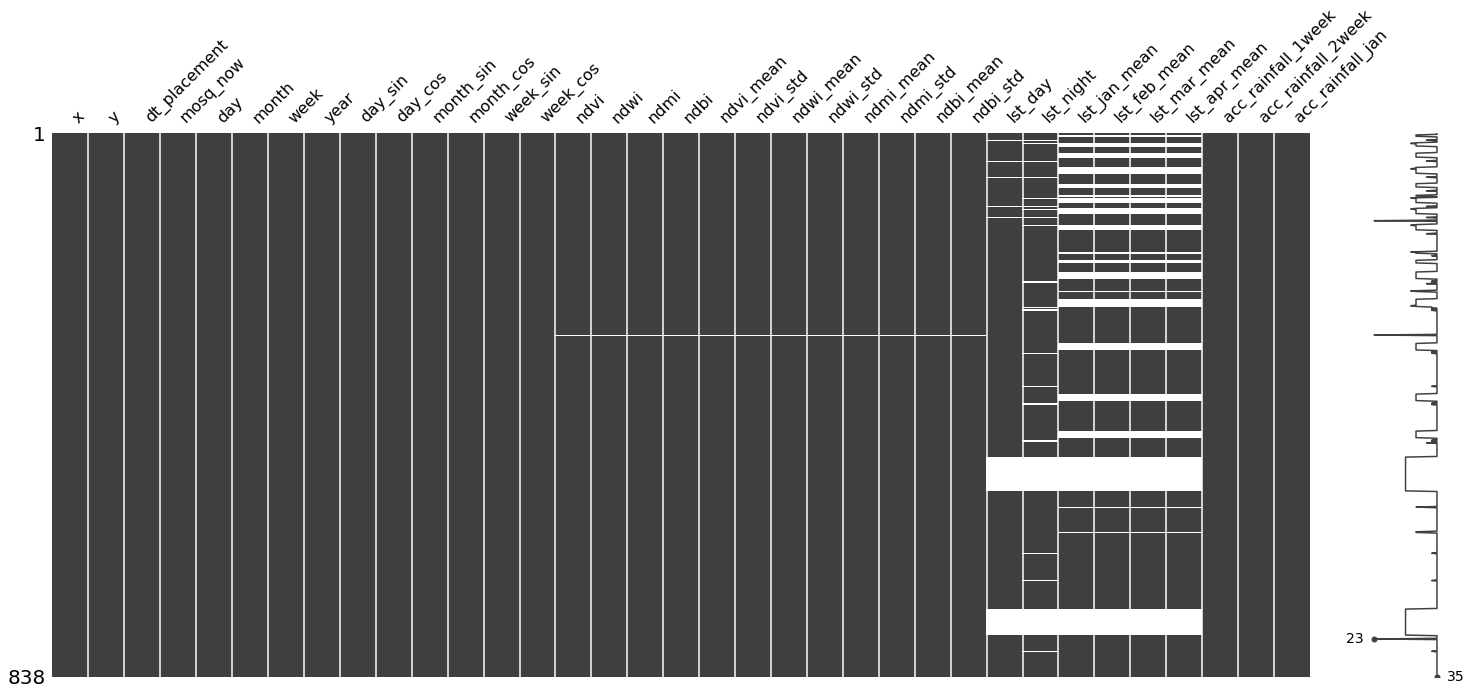

In [12]:
missingno.matrix(mosquito_data_nuts2)

In [13]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [14]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

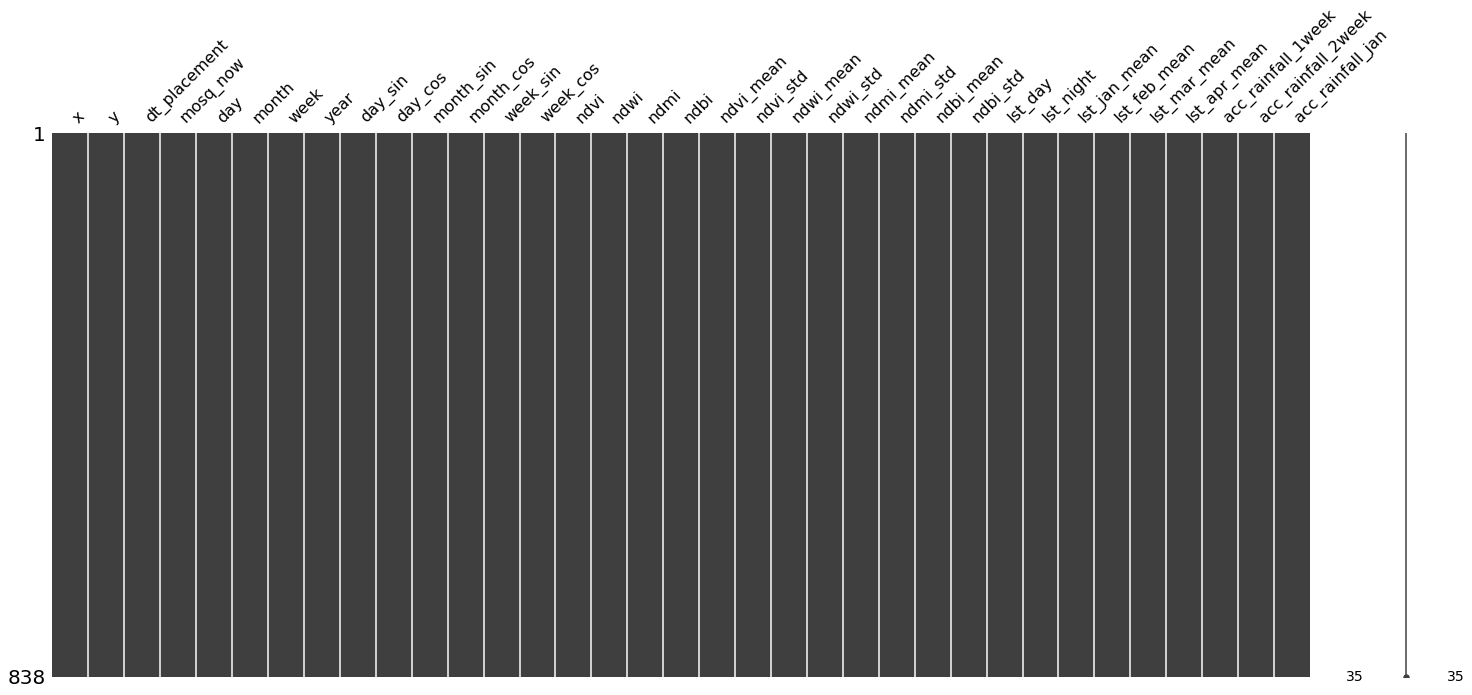

In [15]:
missingno.matrix(mosquito_data_nuts2)

In [16]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [17]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.   16.5 155.3]


In [18]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)


In [19]:
len(train_X[0])

33

Epoch 001: | Train Loss: 41.98381 | Val Loss: 29.07233 | Train Acc: 4.455| Val Acc: 3.422
Epoch 002: | Train Loss: 38.06245 | Val Loss: 29.21195 | Train Acc: 3.785| Val Acc: 3.484
Epoch 003: | Train Loss: 36.08681 | Val Loss: 28.85469 | Train Acc: 3.410| Val Acc: 3.413
Epoch 004: | Train Loss: 35.30002 | Val Loss: 28.10003 | Train Acc: 3.140| Val Acc: 3.194
Epoch 005: | Train Loss: 34.56871 | Val Loss: 27.33720 | Train Acc: 2.994| Val Acc: 2.801
Epoch 006: | Train Loss: 34.39089 | Val Loss: 25.71157 | Train Acc: 2.908| Val Acc: 2.546
Epoch 007: | Train Loss: 33.49620 | Val Loss: 24.63090 | Train Acc: 2.866| Val Acc: 2.419
Epoch 008: | Train Loss: 33.31881 | Val Loss: 23.63388 | Train Acc: 2.791| Val Acc: 2.026
Epoch 009: | Train Loss: 32.76132 | Val Loss: 23.12929 | Train Acc: 2.709| Val Acc: 1.839
Epoch 010: | Train Loss: 33.33973 | Val Loss: 23.29660 | Train Acc: 2.723| Val Acc: 2.149
Epoch 011: | Train Loss: 33.13088 | Val Loss: 23.25074 | Train Acc: 2.650| Val Acc: 1.969
Epoch 012:

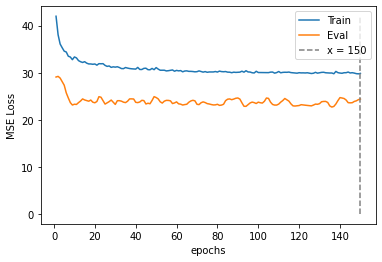

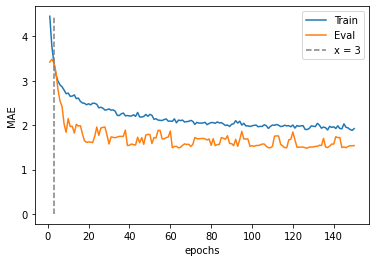

In [20]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [21]:
metrics(train, test, threshold=30)

MAE on train set:  20.794514360482346
min prediction: 1
max prediction: 198

MAE on test set:  24.153435241915126
Error ⩽ 30: 70.99 %
min prediction: 1
max prediction: 207


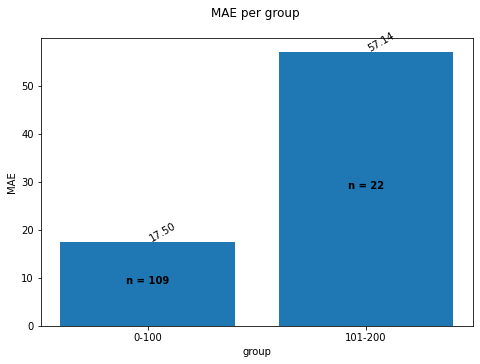

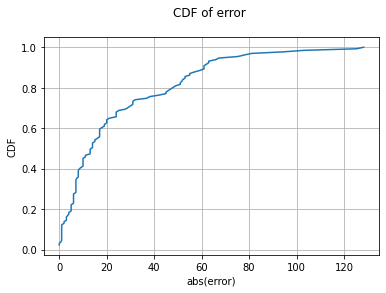

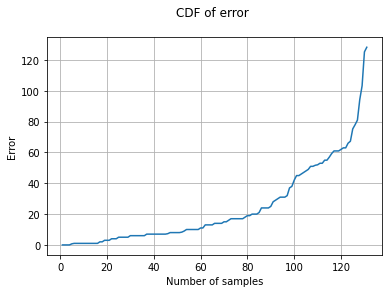

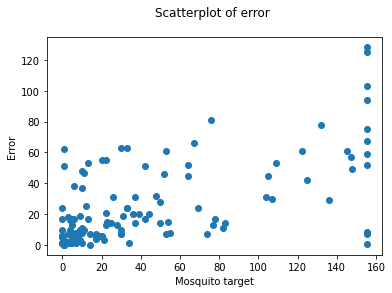

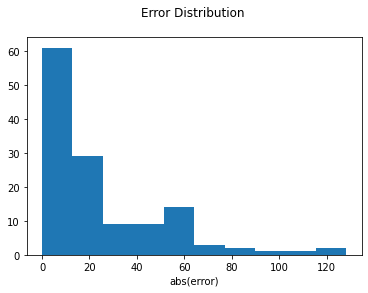

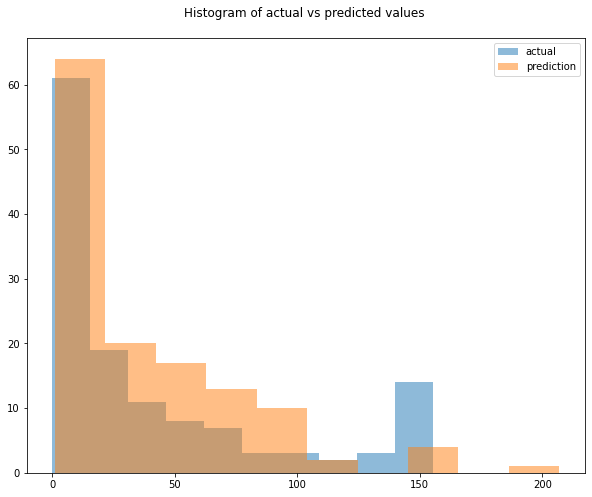

In [22]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 33.89875 | Val Loss: 0.00569 | Train Acc: 2.387| Val Acc: 0.045
Epoch 002: | Train Loss: 32.84206 | Val Loss: 0.08155 | Train Acc: 2.253| Val Acc: 0.045
Epoch 003: | Train Loss: 32.95827 | Val Loss: 0.11921 | Train Acc: 2.181| Val Acc: 0.045
Epoch 004: | Train Loss: 32.76226 | Val Loss: 0.25070 | Train Acc: 2.200| Val Acc: 0.045
Epoch 005: | Train Loss: 32.57682 | Val Loss: 0.32457 | Train Acc: 2.164| Val Acc: 1.045
Epoch 006: | Train Loss: 32.83885 | Val Loss: 0.24762 | Train Acc: 2.167| Val Acc: 0.045
Epoch 007: | Train Loss: 32.57985 | Val Loss: 0.04830 | Train Acc: 2.162| Val Acc: 0.045
Epoch 008: | Train Loss: 32.63753 | Val Loss: 0.06119 | Train Acc: 2.139| Val Acc: 0.045
Epoch 009: | Train Loss: 32.36963 | Val Loss: 0.05700 | Train Acc: 2.148| Val Acc: 0.045
Epoch 010: | Train Loss: 32.29960 | Val Loss: 0.03371 | Train Acc: 2.118| Val Acc: 0.045
Epoch 011: | Train Loss: 32.61533 | Val Loss: 0.06175 | Train Acc: 2.094| Val Acc: 0.045
Epoch 012: | Train Lo

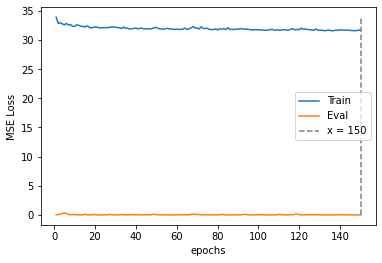

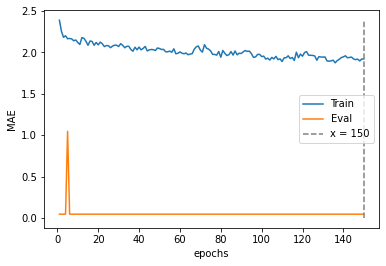

In [23]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [24]:
# torch.save(model.state_dict(), f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Mamoth_Model.pt')
# torch.save(model, f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Mamoth_Model.pth')

In [25]:
pickle.dump(model, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Mamoth_NN.pt', 'wb'))
pickle.dump(imputer, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_KNN_Imputer.pkl', 'wb'))
pickle.dump(scaler, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Scaler.pkl', 'wb'))